> **Scope note.** This notebook is the exploratory analysis over the **full labelled corpus** (1,110,153 Reddit and 378,267 YouTube comments).
>
> The figures reported in the paper come from **`06_revision/`**, which restricts both platforms to the matched 7 October 2023 to 7 May 2024 window and removes automated accounts, leaving 1,004,629 Reddit comments. Where the two differ, `06_revision/` is authoritative.

# RQ3: Polarization and Echo Chambers

**Research Question 3 - Do echo chambers exist and are users polarized?**

This module studies the *structure* of the discourse:

1. **Engagement regression** - does sentiment/stance predict a comment's score? (OLS)
2. **Algorithmic amplification** - are controversial comments scored differently?
3. **Narrative complexity** - readability of comments by platform and stance.
4. **Temporal activity** - monthly volume (Reddit by comment date, YouTube by video publish date).
5. **User stance profiling** - dominant stance and consistency per user.
6. **Echo-chamber detection** - homophily: do users stay in same-stance threads?
7. **Interaction network** - user-user graph projected from shared threads.
8. **ML stance classification** - within- and cross-platform stance prediction.

Self-contained helpers replace `statsmodels`/`textstat` so the notebook runs with
only the core scientific-Python stack. Data is loaded **once** and reused.

**Stance labels:** `P` = Pro-Palestine, `I` = Pro-Israel, `N` = Neutral.

## 1. Setup, Helpers and Data Loader

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import warnings

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (12, 6)

STANCE_ORDER = ["P", "I", "N"]
STANCE_NAMES = {"P": "Pro-Palestine", "I": "Pro-Israel", "N": "Neutral"}
STANCE_COLORS = {"P": "#2ecc71", "I": "#3498db", "N": "#95a5a6"}


def find_repo_root():
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "data" / "reddit_labeled.csv").exists():
            return candidate
    return here


REPO_ROOT = find_repo_root()
DATA_DIR = REPO_ROOT / "data"
SENTIMENT_DIR = REPO_ROOT / "02_emotional_tone_analysis" / "outputs"
OUTPUT_DIR = REPO_ROOT / "04_echo_chambers" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Dependency-free Flesch Reading Ease (replaces textstat) -----------------
_VOWEL_GROUPS = re.compile(r"[aeiouy]+")


def _syllables(word):
    w = word.lower()
    n = len(_VOWEL_GROUPS.findall(w))
    if w.endswith("e") and n > 1:
        n -= 1
    return max(n, 1)


def flesch_reading_ease(text):
    if not isinstance(text, str):
        return np.nan
    words = re.findall(r"[A-Za-z]+", text)
    if len(words) < 3:
        return np.nan
    sentences = max(len(re.findall(r"[.!?]+", text)), 1)
    syl = sum(_syllables(w) for w in words)
    n = len(words)
    return 206.835 - 1.015 * (n / sentences) - 84.6 * (syl / n)


# --- Dependency-free OLS with inference (replaces statsmodels) ---------------
def ols_fit(y, X, names):
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ beta
    n, k = X.shape
    dof = max(n - k, 1)
    sigma2 = (resid @ resid) / dof
    cov = sigma2 * np.linalg.inv(X.T @ X)
    se = np.sqrt(np.diag(cov))
    t = np.divide(beta, se, out=np.zeros_like(beta), where=se > 0)
    p = 2 * stats.t.sf(np.abs(t), dof)
    r2 = 1 - (resid @ resid) / max(((y - y.mean()) ** 2).sum(), 1e-12)
    return pd.DataFrame({"coef": beta, "std_err": se, "t": t, "p_value": p},
                        index=names), r2, n


def _vader_labels(texts):
    an = SentimentIntensityAnalyzer()

    def lab(t):
        if not isinstance(t, str) or t == "":
            return ("neutral", 0.0)
        c = an.polarity_scores(t)["compound"]
        label = "positive" if c >= 0.05 else "negative" if c <= -0.05 else "neutral"
        return (label, c)

    res = texts.fillna("").astype(str).map(lab)
    return pd.DataFrame(res.tolist(), columns=["vader_label", "vader_compound"],
                        index=texts.index)


def load_sentiment_data():
    rp = SENTIMENT_DIR / "reddit_with_sentiment.csv"
    yp = SENTIMENT_DIR / "youtube_with_sentiment.csv"
    if rp.exists() and yp.exists():
        print("Loaded sentiment-enriched data from module 02 outputs.")
        reddit, youtube = pd.read_csv(rp), pd.read_csv(yp)
    else:
        print("Module 02 outputs not found - loading data/ and computing VADER (fallback)...")
        reddit = pd.read_csv(DATA_DIR / "reddit_labeled.csv")
        youtube = pd.read_csv(DATA_DIR / "youtube_labeled.csv")
        reddit = reddit[reddit["Label"].isin(STANCE_ORDER)].copy()
        youtube = youtube[youtube["Label"].isin(STANCE_ORDER)].copy()
        reddit = pd.concat([reddit, _vader_labels(reddit["self_text"])], axis=1)
        youtube = pd.concat([youtube, _vader_labels(youtube["text"])], axis=1)

    reddit = reddit[reddit["Label"].isin(STANCE_ORDER)].copy()
    youtube = youtube[youtube["Label"].isin(STANCE_ORDER)].copy()
    for col in ["score", "post_score", "post_upvote_ratio", "controversiality"]:
        if col in reddit.columns:
            reddit[col] = pd.to_numeric(reddit[col], errors="coerce")
    if "likeCount" in youtube.columns:
        youtube["likeCount"] = pd.to_numeric(youtube["likeCount"], errors="coerce")
    return reddit, youtube


print(f"Output dir: {OUTPUT_DIR}")

Output dir: C:\Users\nitro 5\Desktop\Projects\israel_hamas_discourse_analysis\04_echo_chambers\outputs


## 2. Load Data (once)

In [2]:
reddit_df, youtube_df = load_sentiment_data()

# Standardised text column so cross-platform code is uniform
reddit_df["text_std"] = reddit_df["self_text"].fillna("")
youtube_df["text_std"] = youtube_df["text"].fillna("")

# Parse timestamps used by the temporal / response-time sections
for col in ["created_time", "post_created_time"]:
    if col in reddit_df.columns:
        reddit_df[col] = pd.to_datetime(reddit_df[col], errors="coerce")
youtube_df["created_time"] = pd.to_datetime(youtube_df["created_time"], errors="coerce")

print(f"Reddit : {len(reddit_df):,} rows")
print(f"YouTube: {len(youtube_df):,} rows")

Loaded sentiment-enriched data from module 02 outputs.
Reddit : 1,110,153 rows
YouTube: 378,267 rows


## 3. Engagement Regression (Reddit)

OLS model `score ~ vader_compound + C(stance)` with Pro-Palestine as the reference
category. Coefficients, standard errors, t-statistics and p-values are computed
from first principles.

OLS: score ~ vader_compound + C(stance)   (n=1,110,153, R^2=0.0088)

                   coef  std_err         t  p_value
Intercept       11.0353   0.0475  232.2300   0.0000
vader_compound   2.0432   0.0544   37.5648   0.0000
stance[I] vs P  -0.0960   0.0704   -1.3638   0.1726
stance[N] vs P  -7.3620   0.0811  -90.7236   0.0000


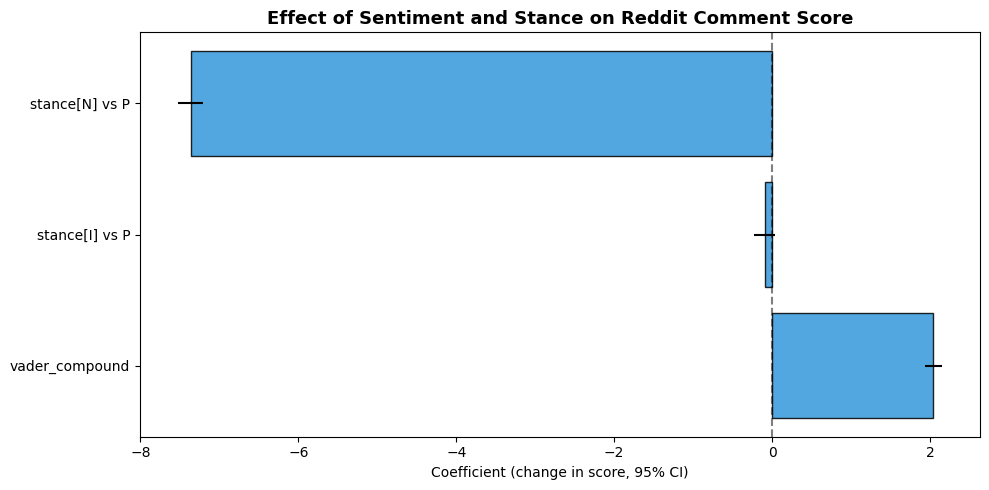

In [3]:
d = reddit_df[["score", "vader_compound", "Label"]].dropna()
d = d[d["Label"].isin(STANCE_ORDER)]
y = d["score"].astype(float).to_numpy()
X = np.column_stack([
    np.ones(len(d)),
    d["vader_compound"].astype(float).to_numpy(),
    (d["Label"] == "I").astype(float).to_numpy(),
    (d["Label"] == "N").astype(float).to_numpy(),
])
names = ["Intercept", "vader_compound", "stance[I] vs P", "stance[N] vs P"]
table, r2, n = ols_fit(y, X, names)
print(f"OLS: score ~ vader_compound + C(stance)   (n={n:,}, R^2={r2:.4f})\n")
print(table.round(4))

# Coefficient plot (exclude intercept)
coefs = table.drop("Intercept")
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(coefs.index, coefs["coef"], xerr=1.96 * coefs["std_err"],
        color="#3498db", edgecolor="black", alpha=0.85)
ax.axvline(0, color="black", linestyle="--", alpha=0.5)
ax.set_title("Effect of Sentiment and Stance on Reddit Comment Score",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Coefficient (change in score, 95% CI)")
plt.tight_layout()
plt.show()

## 4. Algorithmic Amplification (Controversiality)

Mean score by controversiality:
                  mean  median     size
controversiality                       
0                 9.39     2.0  1068772
1                 0.19     1.0    41381


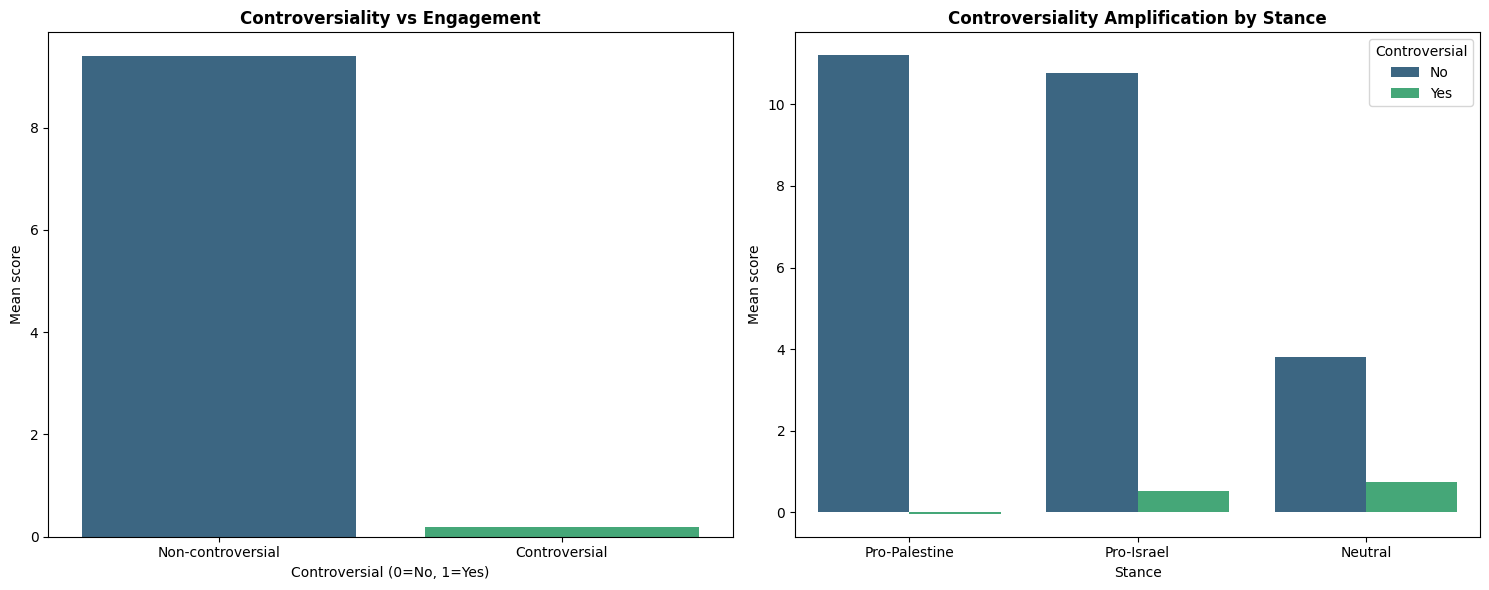

In [4]:
amp = reddit_df[["score", "controversiality", "Label"]].dropna()
amp["controversiality"] = amp["controversiality"].astype(int)
print("Mean score by controversiality:")
print(amp.groupby("controversiality")["score"].agg(["mean", "median", "size"]).round(2))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(data=amp, x="controversiality", y="score", hue="controversiality",
            palette="viridis", legend=False, errorbar=None, ax=axes[0])
axes[0].set_title("Controversiality vs Engagement", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Controversial (0=No, 1=Yes)"); axes[0].set_ylabel("Mean score")
axes[0].set_xticklabels(["Non-controversial", "Controversial"])

amp["stance"] = amp["Label"].map(STANCE_NAMES)
sns.barplot(data=amp, x="stance", y="score", hue="controversiality",
            order=[STANCE_NAMES[s] for s in STANCE_ORDER], palette="viridis",
            errorbar=None, ax=axes[1])
axes[1].set_title("Controversiality Amplification by Stance", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Stance"); axes[1].set_ylabel("Mean score")
axes[1].legend(title="Controversial", labels=["No", "Yes"])
plt.tight_layout()
plt.show()

## 5. Narrative Complexity (Readability)

Flesch Reading Ease (higher = easier to read). Computed on a stratified sample of
up to 150k comments per platform - readability is an auxiliary descriptive metric
and a large sample is statistically ample.

Reddit mean readability : 63.66 (n=143,259)
YouTube mean readability: 67.11 (n=125,305)


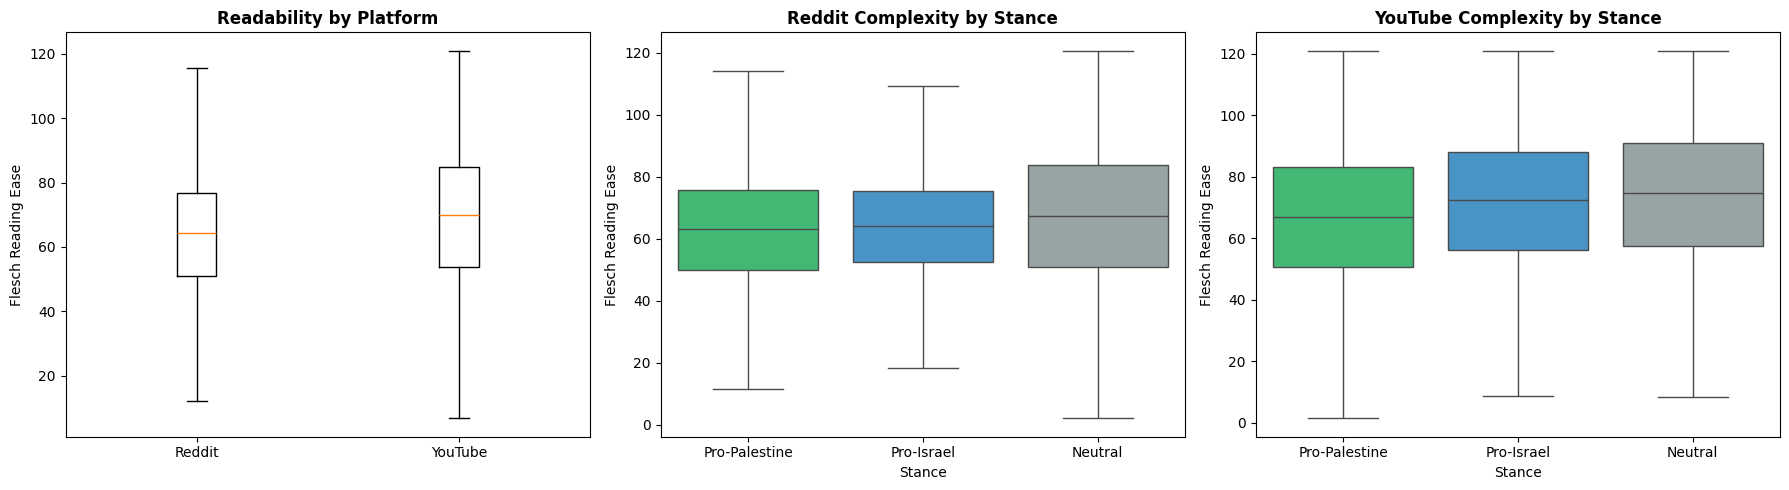

Reddit: Kruskal-Wallis readability ~ stance  H=1101.2, p=7.682e-240
YouTube: Kruskal-Wallis readability ~ stance  H=1464.2, p=0.000e+00


In [5]:
READ_SAMPLE = 150000


def sampled_readability(df, n=READ_SAMPLE):
    sub = df if len(df) <= n else df.groupby("Label", group_keys=False).sample(
        frac=n / len(df), random_state=42)
    return sub.assign(readability=sub["text_std"].map(flesch_reading_ease))


reddit_read = sampled_readability(reddit_df)
youtube_read = sampled_readability(youtube_df)
reddit_read = reddit_read[reddit_read["readability"].between(-100, 121)]
youtube_read = youtube_read[youtube_read["readability"].between(-100, 121)]

print(f"Reddit mean readability : {reddit_read['readability'].mean():.2f} (n={len(reddit_read):,})")
print(f"YouTube mean readability: {youtube_read['readability'].mean():.2f} (n={len(youtube_read):,})")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].boxplot([reddit_read["readability"], youtube_read["readability"]],
                tick_labels=["Reddit", "YouTube"], showfliers=False)
axes[0].set_title("Readability by Platform", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Flesch Reading Ease")

for ax, df, title in [(axes[1], reddit_read, "Reddit"), (axes[2], youtube_read, "YouTube")]:
    sns.boxplot(data=df, x="Label", y="readability", order=STANCE_ORDER,
                hue="Label", hue_order=STANCE_ORDER, palette=STANCE_COLORS,
                legend=False, showfliers=False, ax=ax)
    ax.set_xticklabels([STANCE_NAMES[s] for s in STANCE_ORDER])
    ax.set_title(f"{title} Complexity by Stance", fontsize=12, fontweight="bold")
    ax.set_xlabel("Stance"); ax.set_ylabel("Flesch Reading Ease")
plt.tight_layout()
plt.show()

# Kruskal-Wallis: does readability differ across stances?
for name, df in [("Reddit", reddit_read), ("YouTube", youtube_read)]:
    groups = [df[df["Label"] == s]["readability"].dropna() for s in STANCE_ORDER]
    h, p = stats.kruskal(*groups)
    print(f"{name}: Kruskal-Wallis readability ~ stance  H={h:.1f}, p={p:.3e}")

## 6. Temporal Activity Trends

Reddit by **comment month** (`created_time`); YouTube by **video publish month**
(`video_date`). YouTube `created_time` is the scrape date (runs into 2025-2026),
not the comment time, so `video_date` is the temporal anchor.

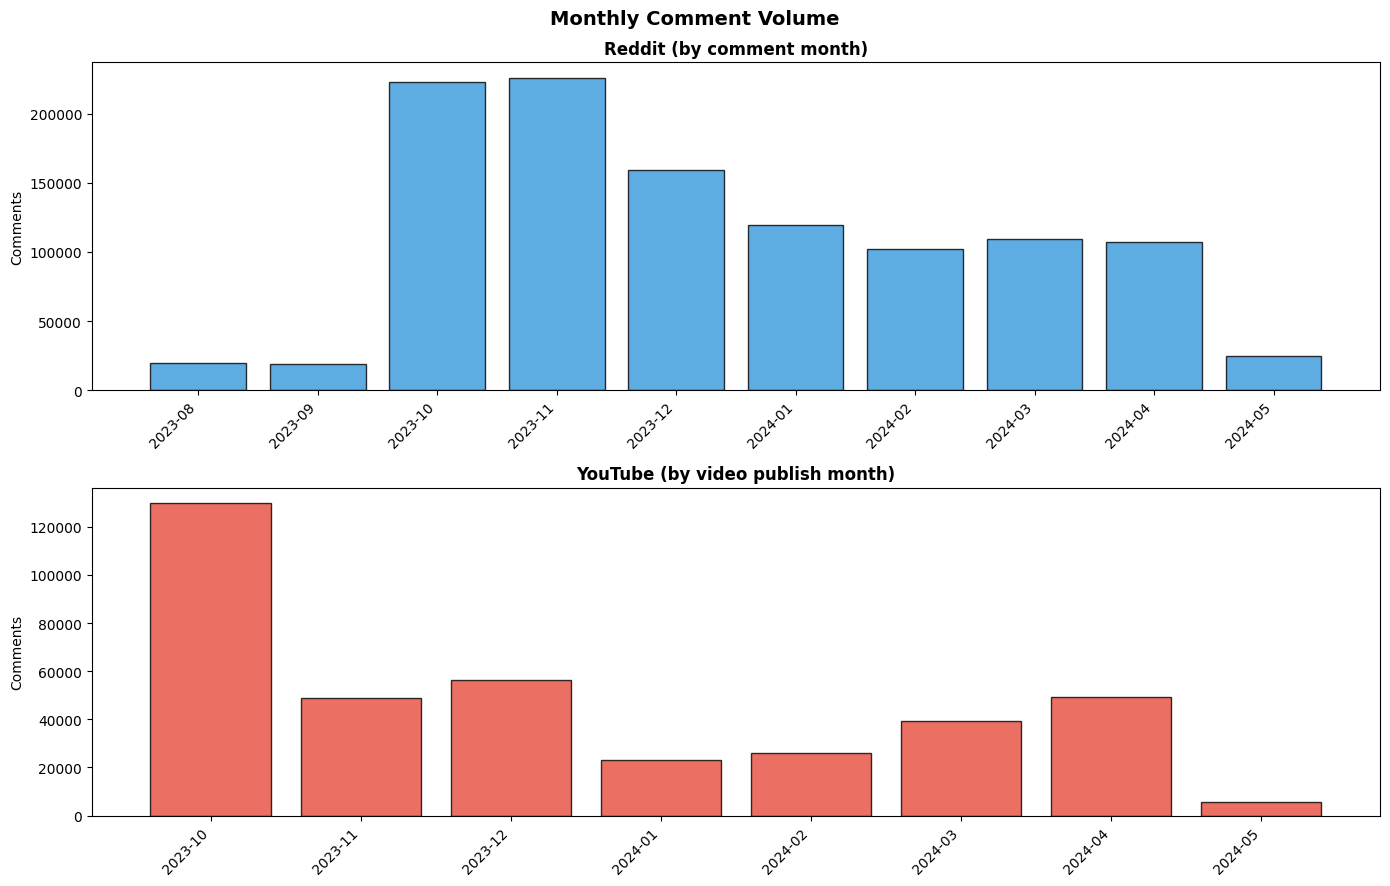

In [6]:
# Reddit -> comment date; YouTube -> video_date (its created_time is the unreliable
# scrape date, not the comment time).
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.suptitle("Monthly Comment Volume", fontsize=14, fontweight="bold")
panels = [("Reddit", reddit_df, "created_time", "comment month", "#3498db"),
          ("YouTube", youtube_df, "video_date", "video publish month", "#e74c3c")]
for ax, (title, df, tcol, tlabel, color) in zip(axes, panels):
    period = pd.to_datetime(df[tcol], errors="coerce").dt.to_period("M")
    vol = df.assign(_period=period).dropna(subset=["_period"]).groupby("_period").size()
    vol.index = vol.index.astype(str)
    ax.bar(vol.index, vol.values, color=color, alpha=0.8, edgecolor="black")
    ax.set_title(f"{title} (by {tlabel})", fontsize=12, fontweight="bold")
    ax.set_ylabel("Comments")
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 7. User Stance Profiling (vectorized)

For Reddit users with >= 3 comments we compute their **dominant stance** and a
**consistency** score (share of their comments in that stance), using group-bys so
it scales to ~100k authors.

**Bots and deleted accounts are excluded** from all user-level analysis (profiling,
homophily, network): `AutoModerator` and `*-ModTeam` are automated accounts, and the
`[deleted]` author lumps thousands of distinct removed accounts into one placeholder.
Left in, they would dominate the "most active users", the homophily index and the
network graph and distort the echo-chamber findings.

Excluded 63,794 bot/deleted comments (5.7%) from user-level analysis.
Real users: 104,414
Active users (>= 3 comments): 46,606

Dominant stance distribution (active users):
dominant_stance
P    24143
I    15694
N     6769
Name: count, dtype: int64


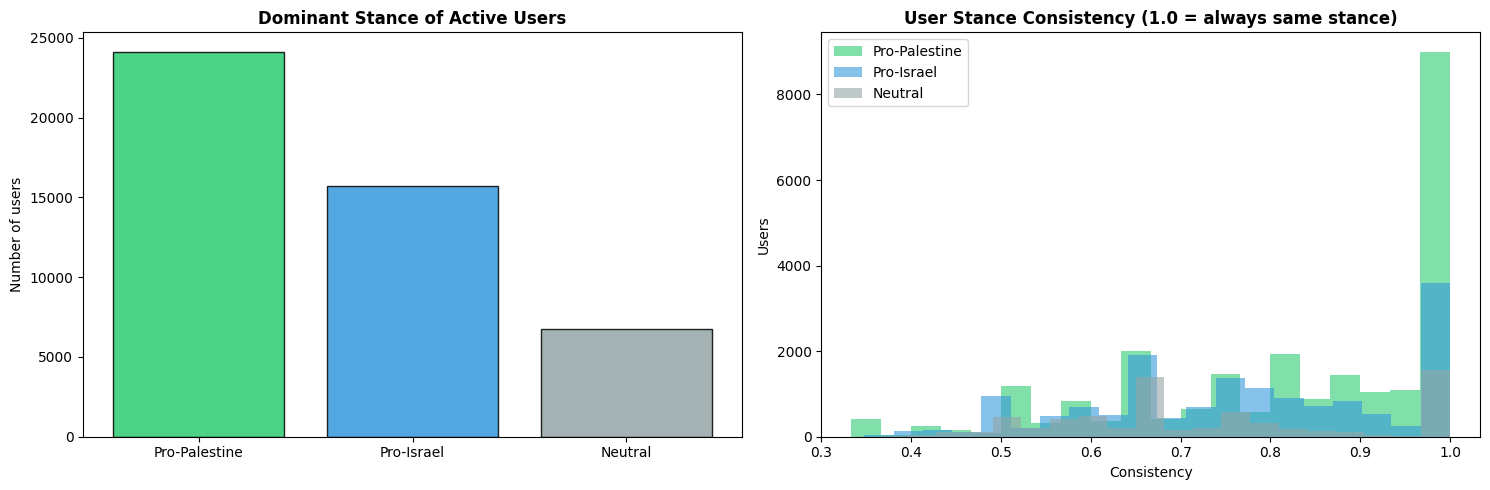


Mean consistency: 0.800


In [7]:
MIN_COMMENTS = 3


def is_real_user(name):
    """Exclude bots and the collapsed '[deleted]' placeholder from user-level analysis."""
    s = str(name)
    if s in {"[deleted]", "[removed]", "AutoModerator"}:
        return False
    return not (s.endswith("ModTeam") or s.endswith("Bot") or s.endswith("-bot"))


ru = reddit_df[reddit_df["author_name"].map(is_real_user)]
print(f"Excluded {len(reddit_df) - len(ru):,} bot/deleted comments "
      f"({(1 - len(ru) / len(reddit_df)) * 100:.1f}%) from user-level analysis.")

counts = (ru.groupby(["author_name", "Label"]).size()
          .unstack(fill_value=0).reindex(columns=STANCE_ORDER, fill_value=0))
totals = counts.sum(axis=1)
active = totals[totals >= MIN_COMMENTS].index

profiles = pd.DataFrame({
    "total_comments": totals,
    "dominant_stance": counts.idxmax(axis=1),
    "consistency": counts.max(axis=1) / totals,
}).loc[active]

print(f"Real users: {len(totals):,}")
print(f"Active users (>= {MIN_COMMENTS} comments): {len(profiles):,}")
print("\nDominant stance distribution (active users):")
print(profiles["dominant_stance"].value_counts().reindex(STANCE_ORDER))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
vc = profiles["dominant_stance"].value_counts().reindex(STANCE_ORDER)
axes[0].bar([STANCE_NAMES[s] for s in STANCE_ORDER], vc.values,
            color=[STANCE_COLORS[s] for s in STANCE_ORDER], edgecolor="black", alpha=0.85)
axes[0].set_title("Dominant Stance of Active Users", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Number of users")

for s in STANCE_ORDER:
    axes[1].hist(profiles[profiles["dominant_stance"] == s]["consistency"],
                 bins=20, alpha=0.6, label=STANCE_NAMES[s], color=STANCE_COLORS[s])
axes[1].set_title("User Stance Consistency (1.0 = always same stance)",
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("Consistency"); axes[1].set_ylabel("Users"); axes[1].legend()
plt.tight_layout()
plt.show()
print(f"\nMean consistency: {profiles['consistency'].mean():.3f}")

## 8. Echo-Chamber Detection (Homophily)

Each thread gets a **majority stance**. A user's **homophily index** is the share
of the distinct threads they participate in whose majority stance matches the
user's own dominant stance. High values indicate same-stance clustering.

Average homophily index: 0.6391
Users in echo chambers (>80% same-stance threads): 19,385 (41.6%)


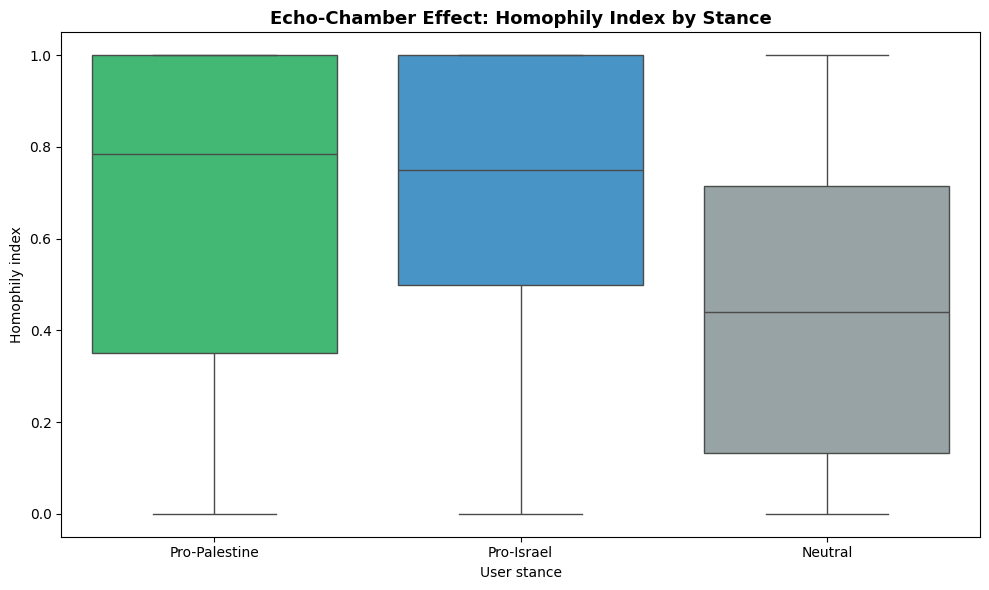

In [8]:
thread_stance = reddit_df.groupby("post_id")["Label"].agg(
    lambda x: x.mode().iloc[0] if not x.mode().empty else "N")

pairs = (reddit_df[reddit_df["author_name"].isin(active)]
         .drop_duplicates(["author_name", "post_id"])
         .loc[:, ["author_name", "post_id"]])
pairs["thread_stance"] = pairs["post_id"].map(thread_stance)
pairs["user_stance"] = pairs["author_name"].map(profiles["dominant_stance"])
pairs["match"] = pairs["thread_stance"] == pairs["user_stance"]

homophily = pairs.groupby("author_name")["match"].mean().rename("homophily_index")
homophily = homophily.to_frame()
homophily["dominant_stance"] = profiles["dominant_stance"]

print(f"Average homophily index: {homophily['homophily_index'].mean():.4f}")
echo = homophily[homophily["homophily_index"] > 0.8]
print(f"Users in echo chambers (>80% same-stance threads): "
      f"{len(echo):,} ({len(echo)/len(homophily):.1%})")

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=homophily, x="dominant_stance", y="homophily_index",
            order=STANCE_ORDER, hue="dominant_stance", hue_order=STANCE_ORDER,
            palette=STANCE_COLORS, legend=False, ax=ax)
ax.set_xticklabels([STANCE_NAMES[s] for s in STANCE_ORDER])
ax.set_title("Echo-Chamber Effect: Homophily Index by Stance", fontsize=13, fontweight="bold")
ax.set_xlabel("User stance"); ax.set_ylabel("Homophily index")
plt.tight_layout()
plt.show()

## 9. User Interaction Network

Bipartite user-thread graph (top 50 most active users) projected onto a user-user
graph: two users are linked if they commented on the same thread. Nodes coloured
by dominant stance.

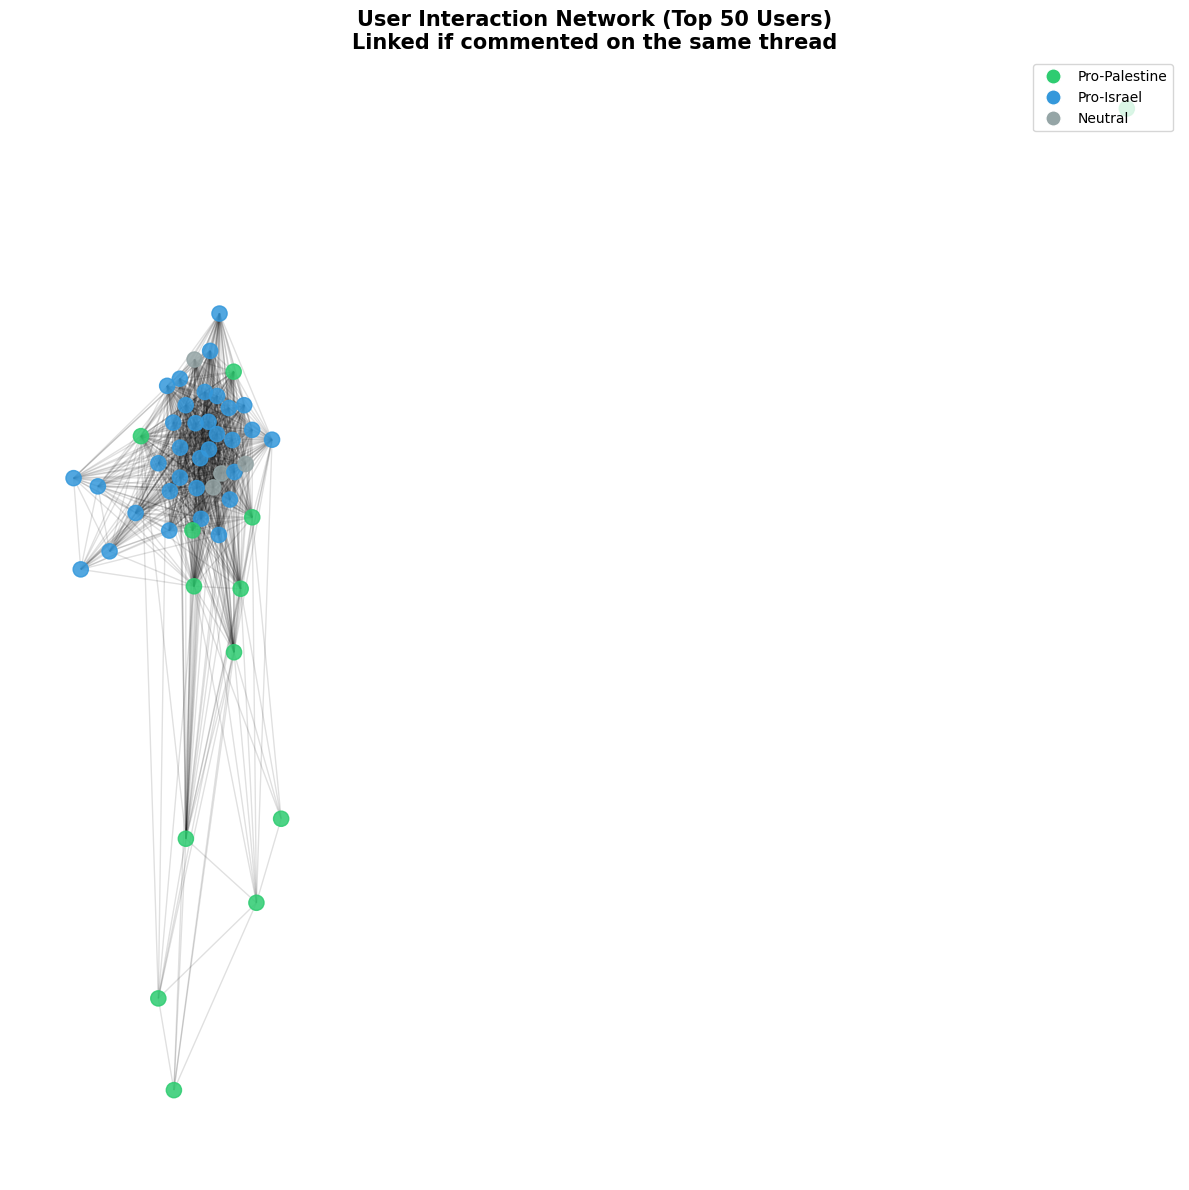

In [9]:
top_users = totals.sort_values(ascending=False).head(50).index
subset = reddit_df[reddit_df["author_name"].isin(top_users)]

B = nx.Graph()
B.add_nodes_from(subset["author_name"].unique(), bipartite=0)
B.add_nodes_from(("post::" + subset["post_id"].astype(str)).unique(), bipartite=1)
B.add_edges_from(zip(subset["author_name"], "post::" + subset["post_id"].astype(str)))

user_nodes = set(subset["author_name"].unique())
G = nx.bipartite.weighted_projected_graph(B, user_nodes)

dom = counts.loc[top_users].idxmax(axis=1)
node_colors = [STANCE_COLORS.get(dom.get(node, "N"), "#95a5a6") for node in G.nodes()]

plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G, k=0.5, iterations=50, seed=42)
nx.draw_networkx_nodes(G, pos, node_size=120, node_color=node_colors, alpha=0.85)
nx.draw_networkx_edges(G, pos, alpha=0.12)
from matplotlib.lines import Line2D
plt.legend(handles=[Line2D([0], [0], marker="o", color="w", label=STANCE_NAMES[s],
                           markerfacecolor=STANCE_COLORS[s], markersize=11)
                    for s in STANCE_ORDER], loc="upper right")
plt.title("User Interaction Network (Top 50 Users)\nLinked if commented on the same thread",
          fontsize=15, fontweight="bold")
plt.axis("off")
plt.tight_layout()
plt.show()

## 10. ML Stance Classification

A soft-voting ensemble - **Logistic Regression + calibrated Linear SVM + Random
Forest** - predicts stance from comment text (TF-IDF, 1-2 grams). Training is
capped at a stratified 60k sample so the ensemble (including the SVM) trains in a
couple of minutes; evaluation uses a held-out 50k sample. We test both
within-platform and cross-platform generalization.

In [10]:
MAX_TRAIN, MAX_EVAL = 60000, 50000


def stratified_cap(df, n):
    return df if len(df) <= n else df.groupby("Label", group_keys=False).sample(
        frac=n / len(df), random_state=42)


def get_ensemble():
    lr = LogisticRegression(max_iter=1000, class_weight="balanced")
    svm = CalibratedClassifierCV(LinearSVC(class_weight="balanced", max_iter=3000), cv=3)
    rf = RandomForestClassifier(n_estimators=100, class_weight="balanced",
                                n_jobs=-1, random_state=42)
    return VotingClassifier([("lr", lr), ("svm", svm), ("rf", rf)], voting="soft")


def train_evaluate(train_df, test_df, train_name, test_name):
    tr = stratified_cap(train_df, MAX_TRAIN)
    te = stratified_cap(test_df, MAX_EVAL)
    print(f"\nTrain on {train_name} (n={len(tr):,}) -> Test on {test_name} (n={len(te):,})")
    tfidf = TfidfVectorizer(max_features=5000, stop_words="english",
                            ngram_range=(1, 2), min_df=5)
    Xtr = tfidf.fit_transform(tr["text_std"])
    Xte = tfidf.transform(te["text_std"])
    model = get_ensemble().fit(Xtr, tr["Label"])
    pred = model.predict(Xte)
    acc = accuracy_score(te["Label"], pred)
    f1 = f1_score(te["Label"], pred, average="macro")
    print(f"  Accuracy={acc:.4f}  Macro-F1={f1:.4f}")
    print(classification_report(te["Label"], pred, target_names=[STANCE_NAMES[s] for s in STANCE_ORDER]))
    cm = confusion_matrix(te["Label"], pred, labels=STANCE_ORDER)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=STANCE_ORDER, yticklabels=STANCE_ORDER)
    plt.title(f"{train_name} -> {test_name}  (acc={acc:.2%})")
    plt.ylabel("Actual"); plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()
    return model, tfidf


print("Ensemble and evaluation helpers ready.")

Ensemble and evaluation helpers ready.


EXPERIMENT 1: WITHIN-PLATFORM PREDICTION

Train on Reddit (n=60,001) -> Test on Reddit (n=50,000)
  Accuracy=0.6619  Macro-F1=0.6535
               precision    recall  f1-score   support

Pro-Palestine       0.67      0.60      0.63     16692
   Pro-Israel       0.60      0.66      0.63     11031
      Neutral       0.69      0.71      0.70     22277

     accuracy                           0.66     50000
    macro avg       0.65      0.66      0.65     50000
 weighted avg       0.66      0.66      0.66     50000



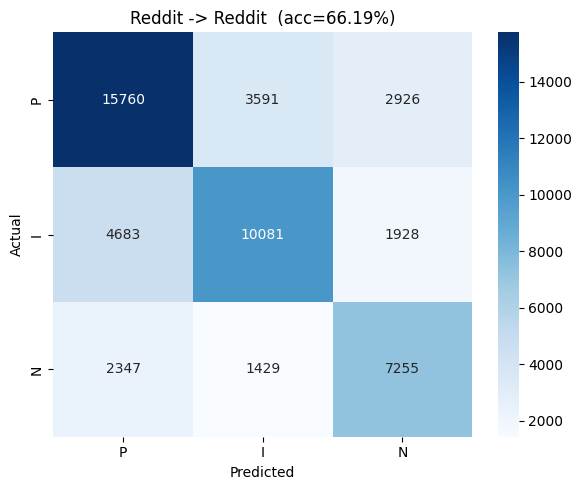


Train on YouTube (n=60,000) -> Test on YouTube (n=50,000)
  Accuracy=0.6220  Macro-F1=0.4836
               precision    recall  f1-score   support

Pro-Palestine       0.59      0.46      0.52     17363
   Pro-Israel       0.27      0.17      0.21      4586
      Neutral       0.66      0.80      0.72     28051

     accuracy                           0.62     50000
    macro avg       0.51      0.48      0.48     50000
 weighted avg       0.60      0.62      0.60     50000



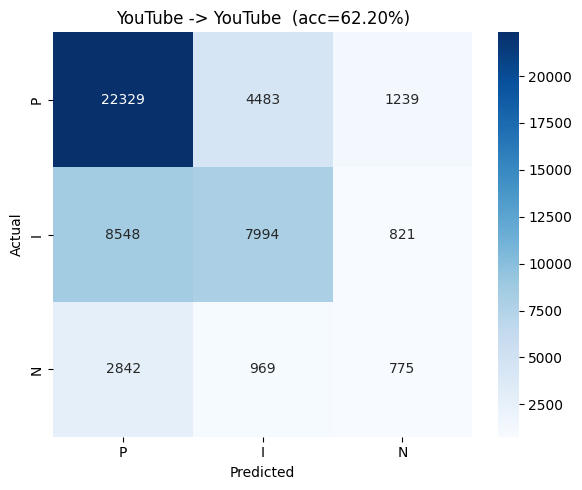

In [11]:
# Experiment 1: within-platform
print("=" * 60)
print("EXPERIMENT 1: WITHIN-PLATFORM PREDICTION")
print("=" * 60)
r_train, r_test = train_test_split(reddit_df, test_size=0.2, random_state=42,
                                   stratify=reddit_df["Label"])
reddit_model, reddit_tfidf = train_evaluate(r_train, r_test, "Reddit", "Reddit")

y_train, y_test = train_test_split(youtube_df, test_size=0.2, random_state=42,
                                   stratify=youtube_df["Label"])
youtube_model, youtube_tfidf = train_evaluate(y_train, y_test, "YouTube", "YouTube")

EXPERIMENT 2: CROSS-PLATFORM GENERALIZATION

Train on Reddit (n=60,001) -> Test on YouTube (n=50,000)
  Accuracy=0.4628  Macro-F1=0.4084
               precision    recall  f1-score   support

Pro-Palestine       0.55      0.32      0.40     17363
   Pro-Israel       0.15      0.54      0.23      4586
      Neutral       0.65      0.54      0.59     28051

     accuracy                           0.46     50000
    macro avg       0.45      0.47      0.41     50000
 weighted avg       0.57      0.46      0.49     50000



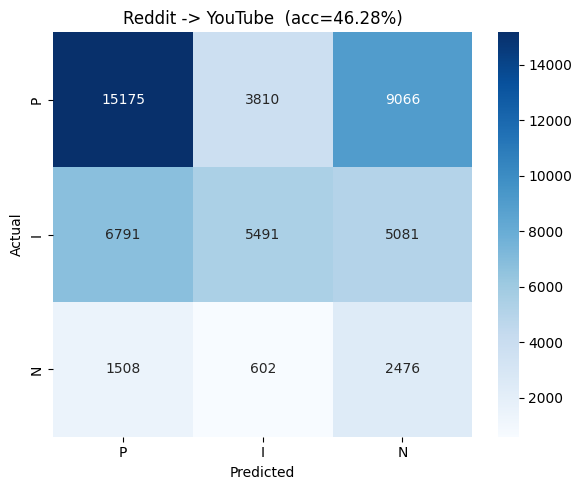


Train on YouTube (n=60,000) -> Test on Reddit (n=50,000)
  Accuracy=0.5361  Macro-F1=0.4391
               precision    recall  f1-score   support

Pro-Palestine       0.56      0.45      0.50     16692
   Pro-Israel       0.58      0.11      0.18     11031
      Neutral       0.52      0.81      0.64     22277

     accuracy                           0.54     50000
    macro avg       0.56      0.46      0.44     50000
 weighted avg       0.55      0.54      0.49     50000



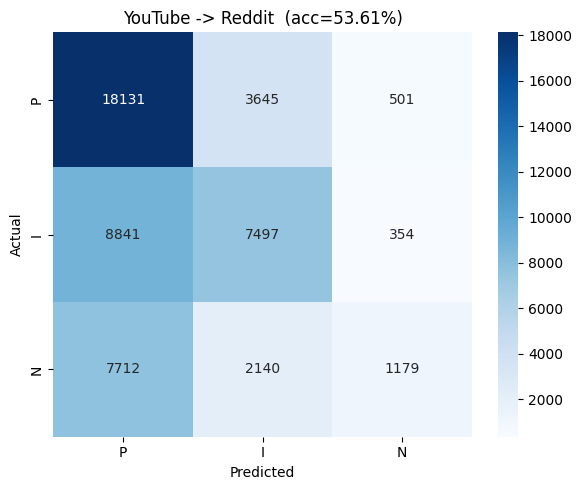

In [12]:
# Experiment 2: cross-platform generalization
print("=" * 60)
print("EXPERIMENT 2: CROSS-PLATFORM GENERALIZATION")
print("=" * 60)
_ = train_evaluate(reddit_df, youtube_df, "Reddit", "YouTube")
_ = train_evaluate(youtube_df, reddit_df, "YouTube", "Reddit")

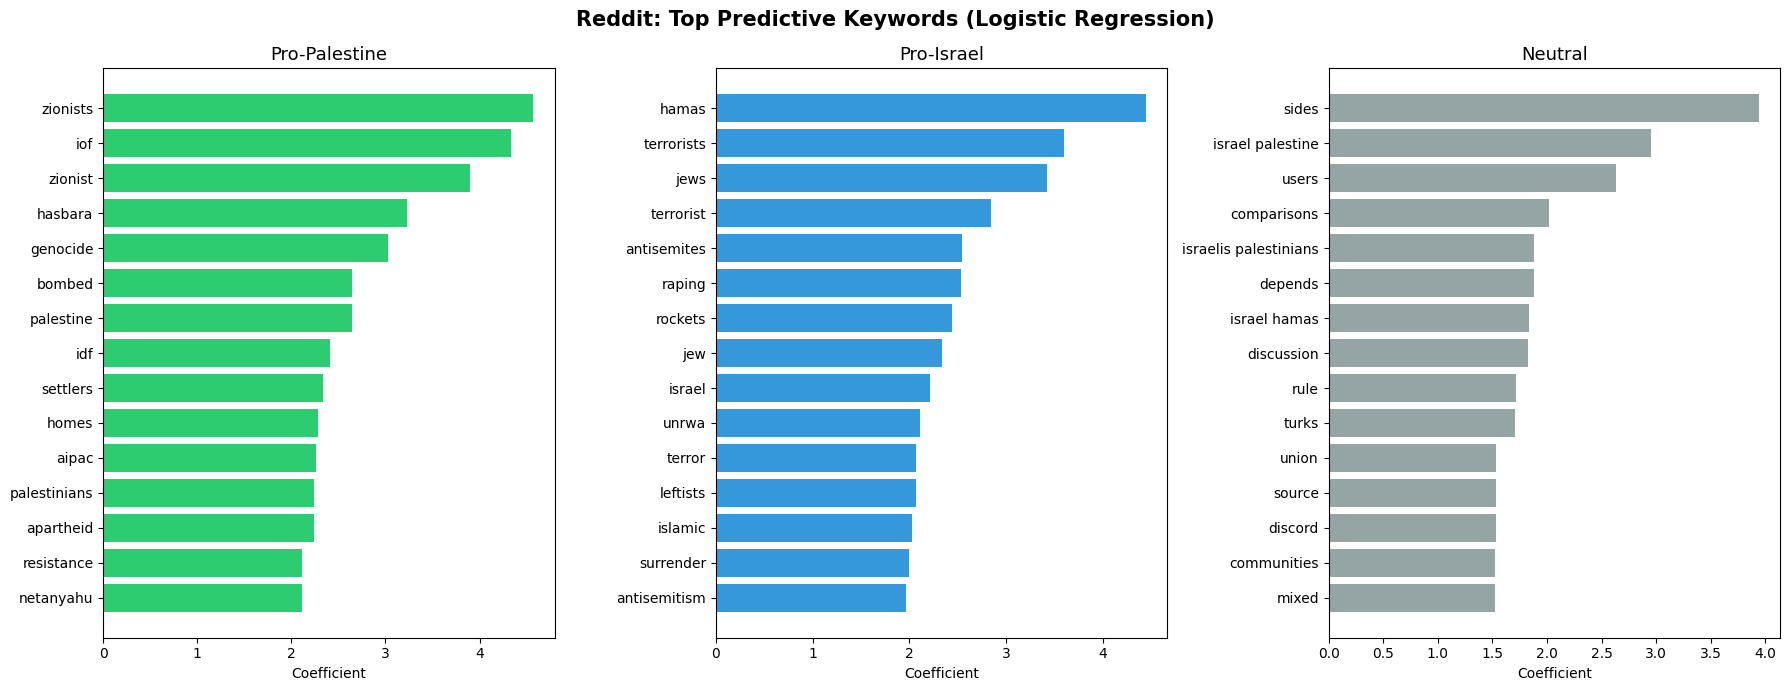

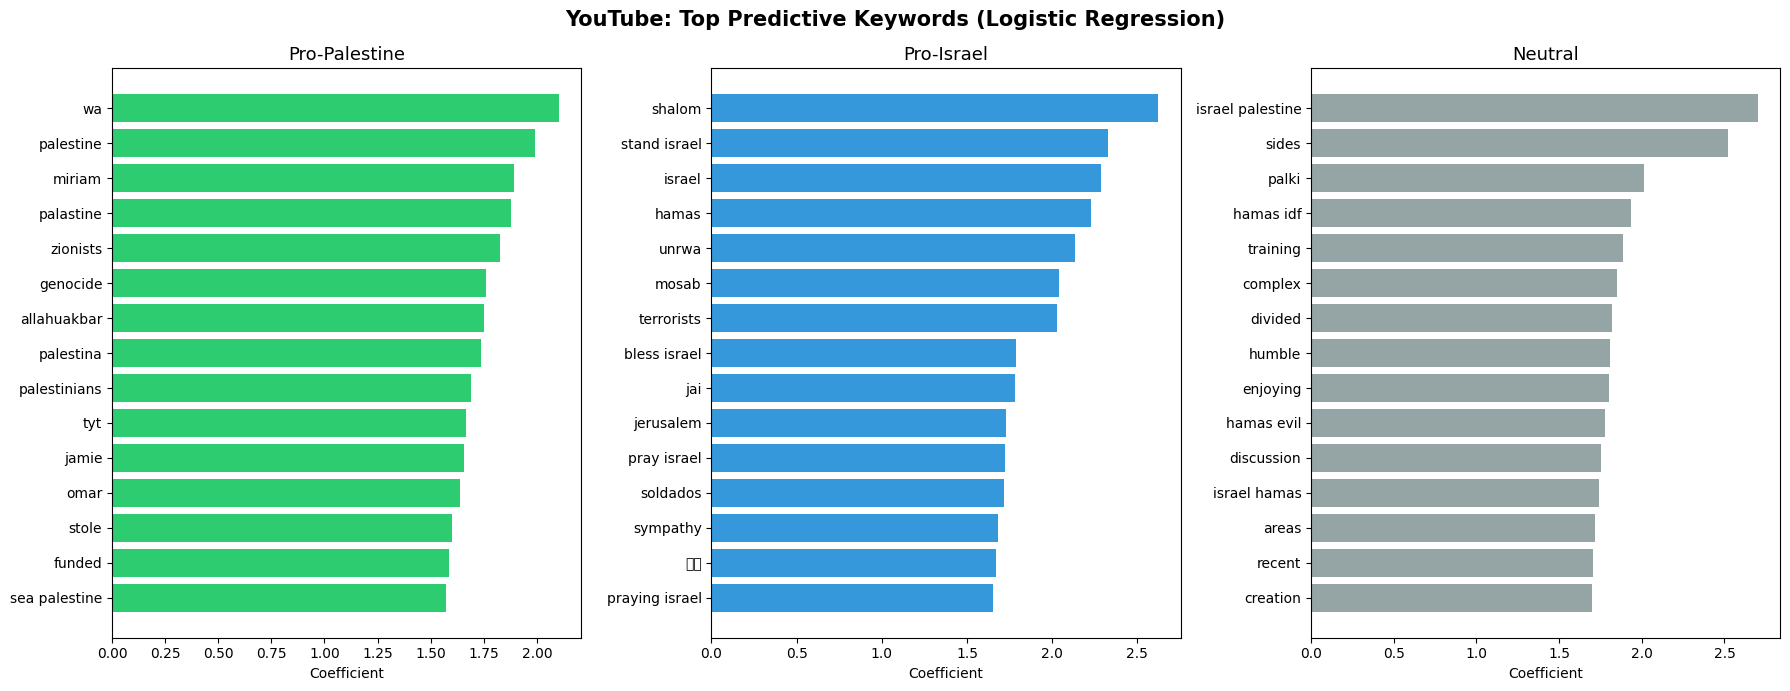

In [13]:
# Feature importance from the Logistic Regression component of each ensemble.
# NOTE: VotingClassifier label-encodes the target internally, so the sub-estimator's
# own .classes_ are integers [0, 1, 2]. The rows of lr.coef_ align to the voting
# classifier's ORIGINAL string labels in model.classes_, so we index with those.
def plot_feature_importance(model, tfidf, title):
    lr = model.named_estimators_["lr"]
    names = tfidf.get_feature_names_out()
    classes = list(model.classes_)  # original stance labels (e.g. [I, N, P]), aligned to lr.coef_ rows
    fig, axes = plt.subplots(1, 3, figsize=(18, 7))
    fig.suptitle(f"{title}: Top Predictive Keywords (Logistic Regression)",
                 fontsize=15, fontweight="bold")
    for ax, stance in zip(axes, STANCE_ORDER):
        if stance not in classes:
            continue
        coefs = lr.coef_[classes.index(stance)]
        idx = np.argsort(coefs)[-15:]
        ax.barh([names[i] for i in idx], coefs[idx], color=STANCE_COLORS[stance])
        ax.set_title(STANCE_NAMES[stance], fontsize=13)
        ax.set_xlabel("Coefficient")
    plt.tight_layout()
    plt.show()


plot_feature_importance(reddit_model, reddit_tfidf, "Reddit")
plot_feature_importance(youtube_model, youtube_tfidf, "YouTube")

## 10b. Cross-Validated Macro-F1

A single train/test split can be optimistic or unlucky. Here we report **Stratified
5-fold cross-validated macro-F1** (mean +/- 95% CI) for the within-platform stance
model, on the capped sample. For speed the CV uses the Logistic Regression component
(a fair, fast proxy for the ensemble).

In [14]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline


def cv_macro_f1(df, name, k=5):
    s = stratified_cap(df, MAX_TRAIN)
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=5000, stop_words="english",
                                  ngram_range=(1, 2), min_df=5)),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
    ])
    cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    scores = cross_val_score(pipe, s["text_std"], s["Label"], cv=cv,
                             scoring="f1_macro", n_jobs=-1)
    ci = 1.96 * scores.std() / np.sqrt(k)
    print(f"{name}: {k}-fold macro-F1 = {scores.mean():.4f} +/- {ci:.4f}  "
          f"(folds: {np.round(scores, 3).tolist()})")
    return scores


_ = cv_macro_f1(reddit_df, "Reddit")
_ = cv_macro_f1(youtube_df, "YouTube")

Reddit: 5-fold macro-F1 = 0.6389 +/- 0.0033  (folds: [0.639, 0.645, 0.634, 0.636, 0.64])
YouTube: 5-fold macro-F1 = 0.4621 +/- 0.0019  (folds: [0.461, 0.461, 0.459, 0.464, 0.465])


## 11. Statistical Summary

In [15]:
print("Echo-chamber homophily by stance (mean index):")
print(homophily.groupby("dominant_stance")["homophily_index"].mean().reindex(STANCE_ORDER).round(3))

# Are homophily distributions different across stances?
groups = [homophily[homophily["dominant_stance"] == s]["homophily_index"] for s in STANCE_ORDER]
groups = [g for g in groups if len(g) > 0]
if len(groups) >= 2:
    h, p = stats.kruskal(*groups)
    print(f"\nKruskal-Wallis homophily ~ stance: H={h:.1f}, p={p:.3e}")

print(f"\nMean user consistency: {profiles['consistency'].mean():.3f}")
print(f"Echo-chamber users (>0.8 homophily): {len(echo)/len(homophily):.1%}")

Echo-chamber homophily by stance (mean index):
dominant_stance
P    0.661
I    0.686
N    0.453
Name: homophily_index, dtype: float64

Kruskal-Wallis homophily ~ stance: H=2043.6, p=0.000e+00

Mean user consistency: 0.800
Echo-chamber users (>0.8 homophily): 41.6%


### Effect Sizes (epsilon-squared)

Standardized effect sizes for the Kruskal-Wallis tests above, so the stance effect on
readability and homophily can be judged independently of the (always tiny) p-values.

In [16]:
def epsilon_squared(h, n):
    return h / (n - 1)


for name, df in [("Reddit", reddit_read), ("YouTube", youtube_read)]:
    groups = [df[df["Label"] == s]["readability"].dropna() for s in STANCE_ORDER]
    h, p = stats.kruskal(*groups)
    n = sum(len(g) for g in groups)
    print(f"{name} readability ~ stance: epsilon^2={epsilon_squared(h, n):.4f}")

groups = [homophily[homophily["dominant_stance"] == s]["homophily_index"] for s in STANCE_ORDER]
groups = [g for g in groups if len(g) > 0]
h, p = stats.kruskal(*groups)
n = sum(len(g) for g in groups)
print(f"homophily ~ stance: epsilon^2={epsilon_squared(h, n):.4f}")

Reddit readability ~ stance: epsilon^2=0.0077
YouTube readability ~ stance: epsilon^2=0.0117
homophily ~ stance: epsilon^2=0.0438


## 12. Export Results

In [17]:
profiles_out = OUTPUT_DIR / "reddit_user_profiles.csv"
homophily_out = OUTPUT_DIR / "reddit_homophily.csv"
profiles.to_csv(profiles_out)
homophily.to_csv(homophily_out)
print(f"Exported: {profiles_out}  ({len(profiles):,} users)")
print(f"Exported: {homophily_out}  ({len(homophily):,} users)")

Exported: C:\Users\nitro 5\Desktop\Projects\israel_hamas_discourse_analysis\04_echo_chambers\outputs\reddit_user_profiles.csv  (46,606 users)
Exported: C:\Users\nitro 5\Desktop\Projects\israel_hamas_discourse_analysis\04_echo_chambers\outputs\reddit_homophily.csv  (46,606 users)


## Summary - RQ3

Each section reports a metric; the direction and magnitude come from the freshly
computed output above, not from any pre-written claim.

- **Engagement** - OLS of score on sentiment + stance, with coef / SE / p-value.
- **Amplification** - mean score for controversial vs non-controversial comments, by stance.
- **Complexity** - Flesch readability by platform and stance (Kruskal-Wallis test).
- **Echo chambers** - per-user dominant stance, a consistency score, and a homophily
  index measuring how often users are in same-stance threads; inspect the printed
  averages and the Kruskal-Wallis result to judge whether echo-chamber structure is present.
- **Network** - the projected interaction graph, coloured by stance.
- **ML** - within- vs cross-platform stance-prediction accuracy and per-stance
  predictive keywords; compare the two to gauge platform-specific framing.

User profiles and homophily indices are exported for reference.